<a href="https://colab.research.google.com/github/adilurahman/car-prediction/blob/main/exam_eurovision_meta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings

#Data Loading and Cleaning

In [4]:


# Load the XLSX file
eurovision_meta= pd.read_excel("/content/partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012.xlsx")

# Save as CSV
eurovision_meta.to_csv("eurovision_meta.csv", index=False)
eurovision_meta.head()


,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [5]:
eurovision_meta.isnull()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,False,False,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
644,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True
645,False,False,False,False,False,False,True,True,False,False,...,True,True,True,True,True,True,True,True,True,True
646,False,False,False,False,False,False,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
eurovision_meta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [7]:
eurovision_meta.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [17]:
#handling missing values with mean in numerical data
missing_values=["Semi.Final.Number","energy","duration","acousticness","danceability","tempo","speechiness","key","liveness","time_signature","mode","loudness","Happiness","valence"]
for i  in missing_values:
  eurovision_meta[i].fillna(
    eurovision_meta[i].mean(),
    inplace=True
)

/tmp/ipykernel_447/2664054745.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  eurovision_meta[i].fillna(


In [15]:
 #replacing missinng valuer with mode in categorical data
missing_values=["Artist.gender","Group.Solo"]
for i in missing_values:
  eurovision_meta[i].fillna(
    eurovision_meta[i].mode()[0],
    inplace=True
)

/tmp/ipykernel_447/844732022.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  eurovision_meta[i].fillna(


In [18]:
eurovision_meta.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


#Intelligent Feature Selection

In [21]:
audio_features = ["energy", "duration", "acousticness", "danceability",
                  "tempo", "speechiness", "key", "liveness",
                  "time_signature", "mode", "loudness", "valence"]


✓ Heatmap saved as 'correlation_heatmap_all_features.png'


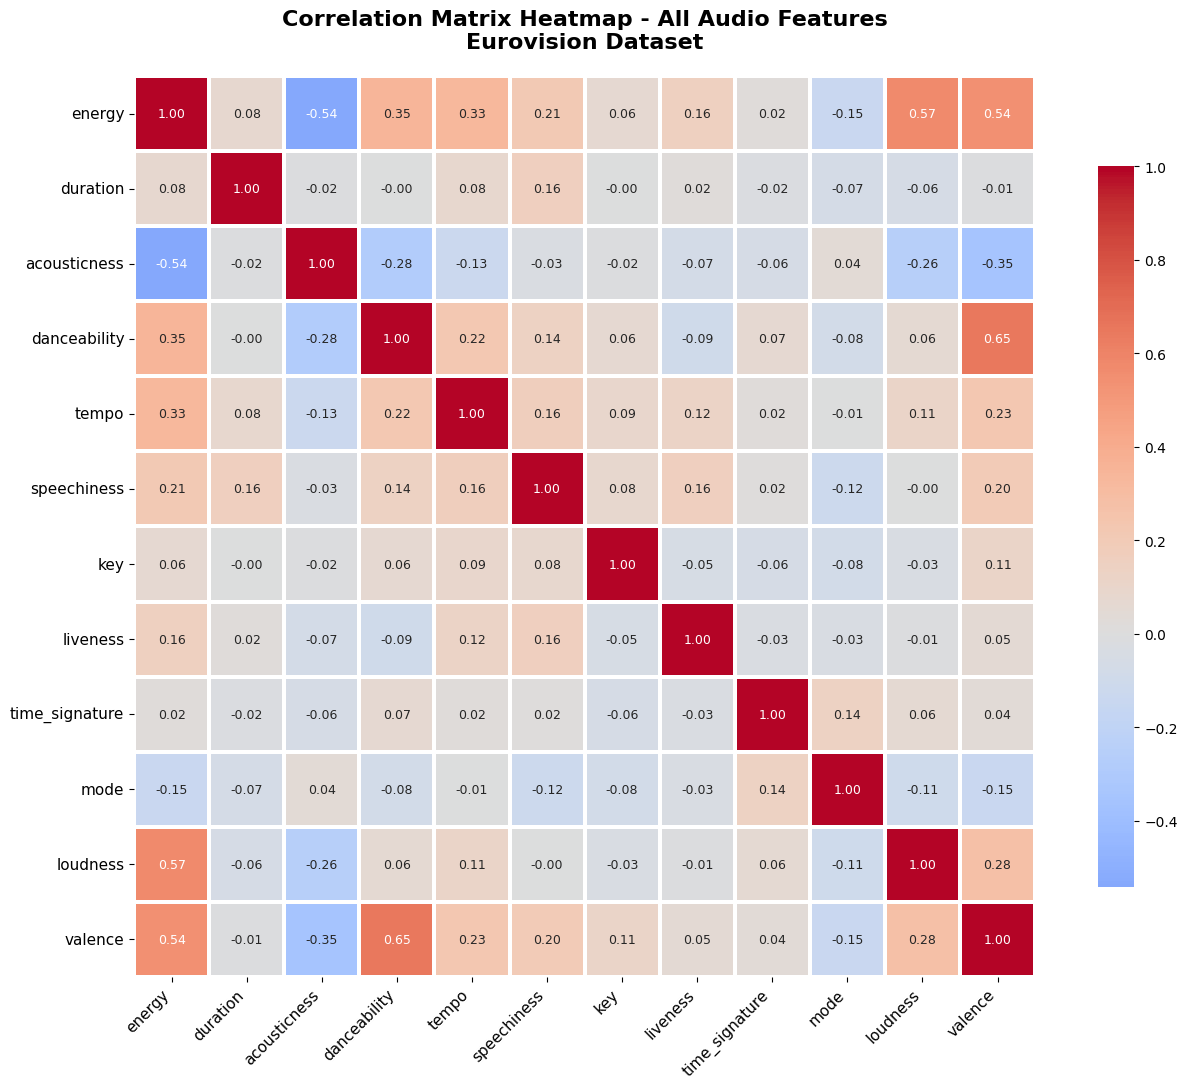

In [22]:
corr_matrix = eurovision_meta[audio_features].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 9})
plt.title('Correlation Matrix Heatmap - All Audio Features\nEurovision Dataset',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('correlation_heatmap_all_features.png', dpi=300, bbox_inches='tight')
print("✓ Heatmap saved as 'correlation_heatmap_all_features.png'")
plt.show()

In [27]:
# Cell 2: Explore Audio Features

# Define all audio features
audio_features = [
    "energy", "duration", "acousticness", "danceability",
    "tempo", "speechiness", "key", "liveness",
    "time_signature", "mode", "loudness", "valence", "Happines"
]

# Filter to only features that exist
audio_features = [col for col in audio_features if col in eurovision_meta.columns]

print("=" * 80)
print("AUDIO FEATURES IDENTIFIED")
print("=" * 80)

print(f"\nTotal features: {len(audio_features)}\n")

print(f"{'#':<3} {'Feature':<20} {'Non-Null':<12} {'Dtype':<12}")
print("-" * 60)

for i, feat in enumerate(audio_features, 1):
    non_null = eurovision_meta[feat].notna().sum()
    dtype = str(eurovision_meta[feat].dtype)
    print(f"{i:<3} {feat:<20} {non_null:<12} {dtype:<12}")

print("\nBasic Statistics:")
print(eurovision_meta[audio_features].describe())

AUDIO FEATURES IDENTIFIED

Total features: 12

#   Feature              Non-Null     Dtype       
------------------------------------------------------------
1   energy               648          float64     
2   duration             648          float64     
3   acousticness         648          float64     
4   danceability         648          float64     
5   tempo                648          float64     
6   speechiness          648          float64     
7   key                  648          float64     
8   liveness             648          float64     
9   time_signature       648          float64     
10  mode                 648          float64     
11  loudness             648          float64     
12  valence              648          float64     

Basic Statistics:
           energy    duration  acousticness  danceability       tempo  \
count  648.000000  648.000000    648.000000    648.000000  648.000000   
mean     0.725833  191.255403      0.164345      0.571246  113.9


CORRELATION MATRIX ANALYSIS

Correlation Matrix (first 8x8):
              energy  duration  acousticness  danceability  tempo  \
energy         1.000     0.077        -0.541         0.346  0.327   
duration       0.077     1.000        -0.017        -0.005  0.081   
acousticness  -0.541    -0.017         1.000        -0.278 -0.127   
danceability   0.346    -0.005        -0.278         1.000  0.223   
tempo          0.327     0.081        -0.127         0.223  1.000   
speechiness    0.212     0.159        -0.029         0.138  0.164   
key            0.065    -0.003        -0.017         0.062  0.093   
liveness       0.156     0.024        -0.074        -0.091  0.123   

              speechiness    key  liveness  
energy              0.212  0.065     0.156  
duration            0.159 -0.003     0.024  
acousticness       -0.029 -0.017    -0.074  
danceability        0.138  0.062    -0.091  
tempo               0.164  0.093     0.123  
speechiness         1.000  0.082     0.163  
k

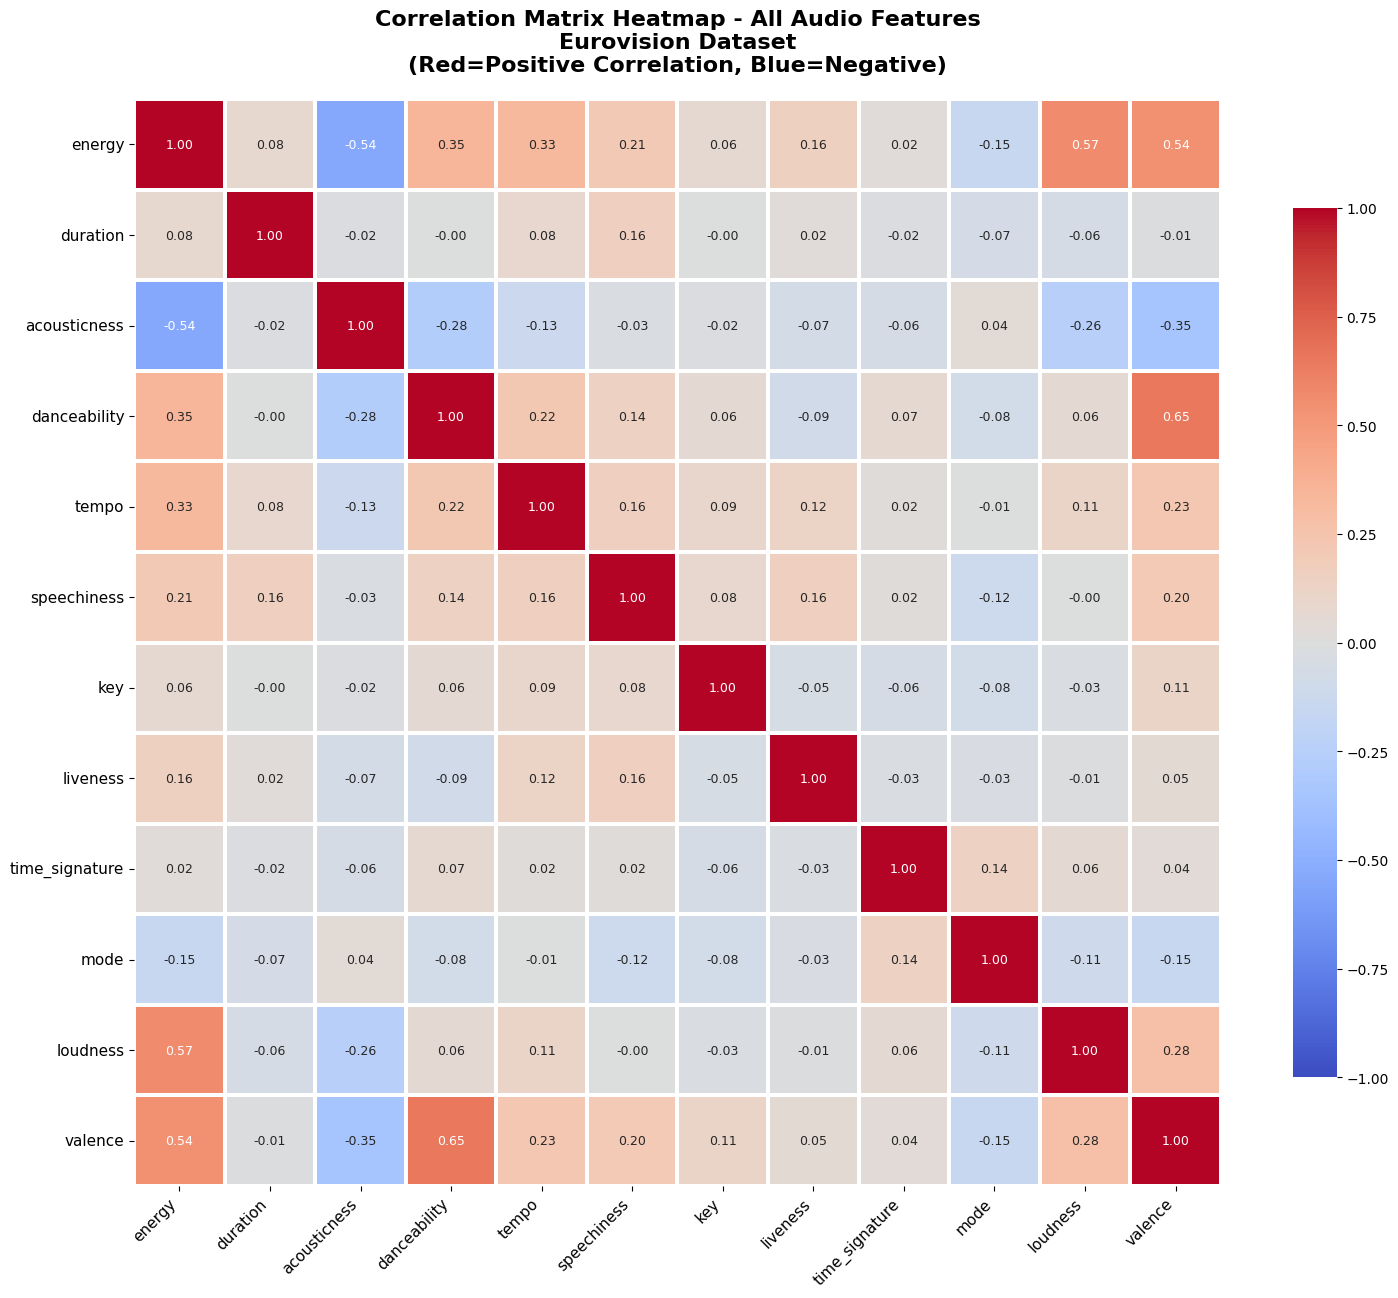


HIGH CORRELATION PAIRS (|r| > 0.7)

✓ No high correlations found (all |r| ≤ 0.7)


In [28]:
#  Create Correlation Matrix & Heatmap

# Calculate correlation matrix
corr_matrix = eurovision_meta[audio_features].corr()

print("\n" + "=" * 80)
print("CORRELATION MATRIX ANALYSIS")
print("=" * 80)

print("\nCorrelation Matrix (first 8x8):")
print(corr_matrix.iloc[:8, :8].round(3))

# Create heatmap visualization
plt.figure(figsize=(16, 13))

sns.heatmap(
    corr_matrix,
    annot=True,                          # Show correlation values
    cmap='coolwarm',                     # Red = positive, Blue = negative
    center=0,                            # Center at 0
    fmt='.2f',                           # 2 decimal places
    square=True,                         # Square cells
    linewidths=1.5,                      # Gridlines
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
    vmin=-1, vmax=1                      # Color scale limits
)

plt.title(
    'Correlation Matrix Heatmap - All Audio Features\nEurovision Dataset\n(Red=Positive Correlation, Blue=Negative)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

# Save the figure
plt.savefig('correlation_heatmap_all_features.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap saved as 'correlation_heatmap_all_features.png'")
plt.show()

# Show high correlations
print("\n" + "=" * 80)
print("HIGH CORRELATION PAIRS (|r| > 0.7)")
print("=" * 80 + "\n")

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, corr_val))
            print(f"🔴 {col1:20} ↔ {col2:20} | r = {corr_val:7.3f}")

if len(high_corr_pairs) == 0:
    print("✓ No high correlations found (all |r| ≤ 0.7)")

In [30]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calculate Variance Inflation Factor (VIF)

# Prepare data (remove missing values)
df_audio = eurovision_meta[audio_features].copy().dropna()

print("=" * 80)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("=" * 80)

print(f"\nDataset rows for VIF calculation: {len(df_audio)}")

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = audio_features
vif_data["VIF"] = [
    variance_inflation_factor(df_audio[audio_features].values, i)
    for i in range(len(audio_features))
]

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF Values (sorted):\n")
print(f"{'Rank':<6} {'Feature':<20} {'VIF':<10} {'Status':<20}")
print("-" * 60)

for idx, row in vif_data.iterrows():
    feature = row['Feature']
    vif_val = row['VIF']

    if vif_val < 5:
        status = "✓ Good"
    elif vif_val < 10:
        status = "⚠️  Concerning"
    else:
        status = "❌ Problematic"

    print(f"{idx+1:<6} {feature:<20} {vif_val:<10.2f} {status:<20}")

print(f"\n\nStatistics:")
print(f"  • Max VIF: {vif_data['VIF'].max():.2f}")
print(f"  • Mean VIF: {vif_data['VIF'].mean():.2f}")
print(f"  • Features with VIF > 5: {len(vif_data[vif_data['VIF'] > 5])}")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS

Dataset rows for VIF calculation: 648

VIF Values (sorted):

Rank   Feature              VIF        Status              
------------------------------------------------------------
1      time_signature       55.72      ❌ Problematic       
2      energy               47.55      ❌ Problematic       
3      danceability         46.07      ❌ Problematic       
4      duration             39.01      ❌ Problematic       
5      tempo                33.51      ❌ Problematic       
6      valence              16.98      ❌ Problematic       
7      loudness             15.73      ❌ Problematic       
8      key                  4.92       ✓ Good              
9      liveness             3.16       ✓ Good              
10     mode                 3.07       ✓ Good              
11     speechiness          3.02       ✓ Good              
12     acousticness         2.27       ✓ Good              


Statistics:
  • Max VIF: 55.72
  • Mean VIF: 22.58
  •

FEATURE SELECTION STRATEGY

✅ SELECTED FEATURES (5 features):

1. ENERGY
   VIF: 47.55
   Mean: 0.726

2. DANCEABILITY
   VIF: 46.07
   Mean: 0.571

3. SPEECHINESS
   VIF: 3.02
   Mean: 0.057

4. ACOUSTICNESS
   VIF: 2.27
   Mean: 0.164

5. LIVENESS
   VIF: 3.16
   Mean: 0.201


Correlation Matrix (Selected Features):

              energy  danceability  speechiness  acousticness  liveness
energy         1.000         0.346        0.212        -0.541     0.156
danceability   0.346         1.000        0.138        -0.278    -0.091
speechiness    0.212         0.138        1.000        -0.029     0.163
acousticness  -0.541        -0.278       -0.029         1.000    -0.074
liveness       0.156        -0.091        0.163        -0.074     1.000


High Correlations in Selected Features:
  ✓ No high correlations - Features are independent!

✓ Selected features heatmap saved


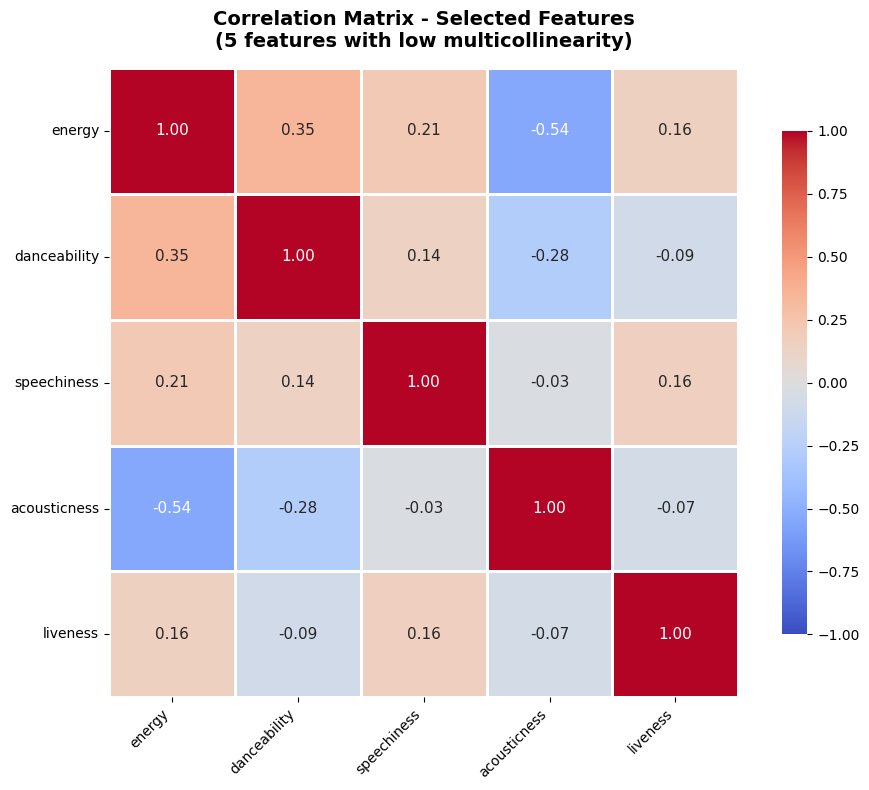

In [32]:
#  Select Reduced Feature Set

# Define selected features based on VIF and correlation analysis
selected_features = [
    "energy",
    "danceability",
    "speechiness",
    "acousticness",
    "liveness"
]

print("=" * 80)
print("FEATURE SELECTION STRATEGY")
print("=" * 80)

print("\n✅ SELECTED FEATURES (5 features):\n")

for i, feat in enumerate(selected_features, 1):
    vif_val = vif_data[vif_data['Feature'] == feat]['VIF'].values[0]
    mean_val = eurovision_meta[feat].mean()

    print(f"{i}. {feat.upper()}")
    print(f"   VIF: {vif_val:.2f}")
    print(f"   Mean: {mean_val:.3f}")
    print()

# Get correlation matrix for selected features
selected_corr = eurovision_meta[selected_features].corr()

print("\nCorrelation Matrix (Selected Features):\n")
print(selected_corr.round(3))

# Check for high correlations in selected set
print("\n\nHigh Correlations in Selected Features:")
high_corr_in_selected = False
for i in range(len(selected_corr.columns)):
    for j in range(i+1, len(selected_corr.columns)):
        corr_val = selected_corr.iloc[i, j]
        if abs(corr_val) > 0.7:
            col1 = selected_corr.columns[i]
            col2 = selected_corr.columns[j]
            print(f"  ⚠️  {col1} ↔ {col2}: r = {corr_val:.3f}")
            high_corr_in_selected = True

if not high_corr_in_selected:
    print("  ✓ No high correlations - Features are independent!")

# Create heatmap for selected features
plt.figure(figsize=(10, 8))

sns.heatmap(
    selected_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=2,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 11},
    vmin=-1, vmax=1
)

plt.title(
    'Correlation Matrix - Selected Features\n(5 features with low multicollinearity)',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('correlation_heatmap_selected_features.png', dpi=300, bbox_inches='tight')
print("\n✓ Selected features heatmap saved")
plt.show()


✓ VIF comparison saved


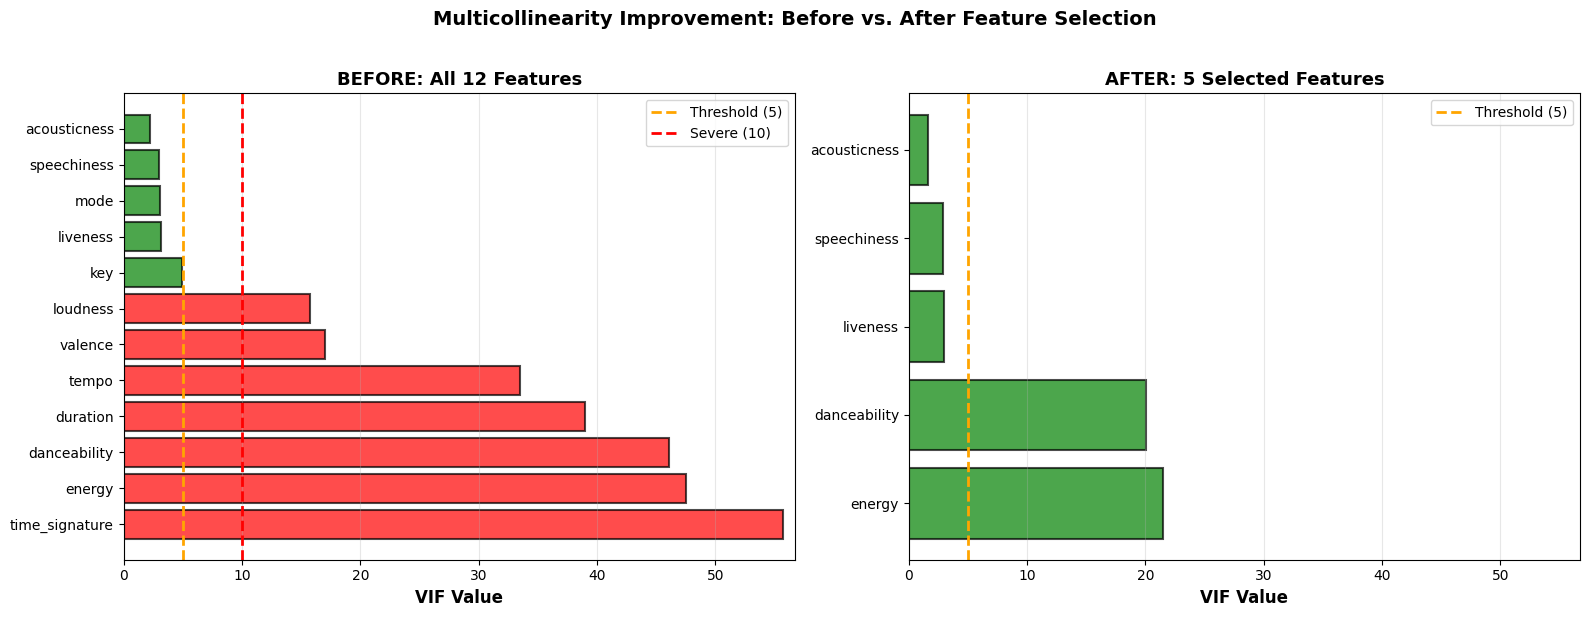


MULTICOLLINEARITY IMPROVEMENT

BEFORE Selection (12 features):
  • Max VIF: 55.72
  • Mean VIF: 22.58
  • Features with VIF > 5: 7

AFTER Selection (5 features):
  • Max VIF: 21.48
  • Mean VIF: 9.79
  • Features with VIF > 5: 2

✅ IMPROVEMENT: 61.5% reduction in multicollinearity!


In [33]:
# Multicollinearity Improvement Comparison

# Calculate VIF for selected features
df_selected = eurovision_meta[selected_features].dropna()
vif_selected = pd.DataFrame()
vif_selected["Feature"] = selected_features
vif_selected["VIF"] = [
    variance_inflation_factor(df_selected[selected_features].values, i)
    for i in range(len(selected_features))
]
vif_selected = vif_selected.sort_values('VIF', ascending=False)

# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before selection
colors_before = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_data['VIF']]
axes[0].barh(vif_data['Feature'], vif_data['VIF'], color=colors_before, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Threshold (5)')
axes[0].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Severe (10)')
axes[0].set_xlabel('VIF Value', fontsize=12, fontweight='bold')
axes[0].set_title(f'BEFORE: All {len(audio_features)} Features', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, vif_data['VIF'].max() + 1)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# After selection
colors_after = ['green' for _ in vif_selected]
axes[1].barh(vif_selected['Feature'], vif_selected['VIF'], color=colors_after, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Threshold (5)')
axes[1].set_xlabel('VIF Value', fontsize=12, fontweight='bold')
axes[1].set_title(f'AFTER: {len(selected_features)} Selected Features', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, vif_data['VIF'].max() + 1)
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Multicollinearity Improvement: Before vs. After Feature Selection',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('VIF_comparison.png', dpi=300, bbox_inches='tight')
print("✓ VIF comparison saved")
plt.show()

# Print statistics
print("\n" + "=" * 80)
print("MULTICOLLINEARITY IMPROVEMENT")
print("=" * 80)

before_max = vif_data['VIF'].max()
after_max = vif_selected['VIF'].max()
improvement = ((before_max - after_max) / before_max * 100)

print(f"\nBEFORE Selection ({len(audio_features)} features):")
print(f"  • Max VIF: {before_max:.2f}")
print(f"  • Mean VIF: {vif_data['VIF'].mean():.2f}")
print(f"  • Features with VIF > 5: {len(vif_data[vif_data['VIF'] > 5])}")

print(f"\nAFTER Selection ({len(selected_features)} features):")
print(f"  • Max VIF: {after_max:.2f}")
print(f"  • Mean VIF: {vif_selected['VIF'].mean():.2f}")
print(f"  • Features with VIF > 5: {len(vif_selected[vif_selected['VIF'] > 5])}")

print(f"\n✅ IMPROVEMENT: {improvement:.1f}% reduction in multicollinearity!")

In [34]:
eurovision_final = eurovision_meta[selected_features].copy()

print("=" * 80)
print("FINAL REDUCED DATASET")
print("=" * 80)

print(f"\nDataset Shape: {eurovision_final.shape}")
print(f"  • Rows: {eurovision_final.shape[0]}")
print(f"  • Columns: {len(selected_features)}")

print("\nFirst 10 rows:")
print(eurovision_final.head(10))

print("\n\nData Quality Check:")
print(f"Total missing values: {eurovision_final.isnull().sum().sum()}")

print("\nSummary Statistics:")
print(eurovision_final.describe())

# Save dataset
eurovision_final.to_csv('eurovision_selected_features.csv', index=False)
print("\n✓ Dataset saved as 'eurovision_selected_features.csv'")

# Display file information
import os
file_size = os.path.getsize('eurovision_selected_features.csv') / 1024
print(f"✓ File size: {file_size:.2f} KB")

print("\n✅ Analysis Complete! Dataset ready for machine learning models.")

FINAL REDUCED DATASET

Dataset Shape: (648, 5)
  • Rows: 648
  • Columns: 5

First 10 rows:
     energy  danceability  speechiness  acousticness  liveness
0  0.678258      0.598360     0.027817      0.563170  0.078643
1  0.794093      0.604542     0.024996      0.068711  0.084805
2  0.574628      0.367344     0.043751      0.654078  0.923905
3  0.672746      0.513202     0.034855      0.119194  0.143708
4  0.733959      0.590592     0.032406      0.323643  0.079322
5  0.606222      0.575144     0.042616      0.266774  0.113280
6  0.648462      0.260856     0.030312      0.120636  0.100348
7  0.920414      0.628108     0.064255      0.006192  0.174562
8  0.868098      0.691723     0.099743      0.368221  0.356402
9  0.948516      0.631655     0.063436      0.652044  0.186245


Data Quality Check:
Total missing values: 0

Summary Statistics:
           energy  danceability  speechiness  acousticness    liveness
count  648.000000    648.000000   648.000000    648.000000  648.000000
mean  

#Exploratory Data Analysis

In [35]:
from scipy import stats

# Load your dataset
# Eurovision_meta should already be loaded
print("=" * 80)
print("DATA EXPLORATION - CHECKING FOR DANCEABILITY AND POINTS")
print("=" * 80)

print(f"\nDataset shape: {eurovision_meta.shape}")
print(f"\nAll columns in dataset:")
print(eurovision_meta.columns.tolist())

print(f"\n\nFirst 5 rows:")
print(eurovision_meta.head())

# Check for Points column (might be named differently)
points_columns = [col for col in eurovision_meta.columns
                  if 'point' in col.lower() or 'score' in col.lower() or 'rank' in col.lower()]

print(f"\n\nPossible Points/Score columns:")
for col in points_columns:
    print(f"  • {col}")

# Check data types and missing values
print(f"\n\nData Info:")
print(f"{'Column':<30} {'Type':<15} {'Non-Null':<12} {'Missing':<12}")
print("-" * 70)

for col in ['danceability', 'Points', 'energy', 'acousticness', 'speechiness', 'liveness']:
    if col in eurovision_meta.columns:
        dtype = str(eurovision_meta[col].dtype)
        non_null = eurovision_meta[col].notna().sum()
        missing = eurovision_meta[col].isna().sum()
        print(f"{col:<30} {dtype:<15} {non_null:<12} {missing:<12}")

DATA EXPLORATION - CHECKING FOR DANCEABILITY AND POINTS

Dataset shape: (648, 30)

All columns in dataset:
['Unnamed: 0', 'Year', 'Country', 'Region', 'Artist', 'Song', 'Artist.gender', 'Group.Solo', 'Place', 'Points', 'Home.Away.Country', 'Home.Away.Region', 'Is.Final', 'Semi.Final.Number', 'Song.In.English', 'Song.Quality', 'Normalized.Points', 'energy', 'duration', 'acousticness', 'danceability', 'tempo', 'speechiness', 'key', 'liveness', 'time_signature', 'mode', 'loudness', 'valence', 'Happiness']


First 5 rows:
   Unnamed: 0  Year    Country                 Region  \
0           1  2009  Lithuania  Former Socialist Bloc   
1           2  2009     Israel            Independent   
2           3  2009     France         Western Europe   
3           4  2009     Sweden            Scandinavia   
4           5  2009    Croatia      Former Yugoslavia   

                      Artist                       Song Artist.gender  \
0                 Sasha Son                        Love     


DATA PREPARATION FOR SCATTER PLOT

Dataset for analysis:
  • Selected features: ['energy', 'danceability', 'speechiness', 'acousticness', 'liveness']
  • Points column: Points
  • Original rows: 648
  • Rows after removing NaN: 648
  • Rows removed: 0


Descriptive Statistics:
       danceability      Points
count    648.000000  648.000000
mean       0.571246   77.783951
std        0.117376   63.301464
min        0.183719    0.000000
25%        0.528208   30.000000
50%        0.571246   62.000000
75%        0.641908  110.000000
max        0.894179  387.000000


Data Quality Check:
  Danceability range: 0.18 to 0.89
  Points range: 0 to 387

CREATING SCATTER PLOT: DANCEABILITY vs POINTS

✓ Basic scatter plot saved as 'scatter_danceability_vs_points_basic.png'


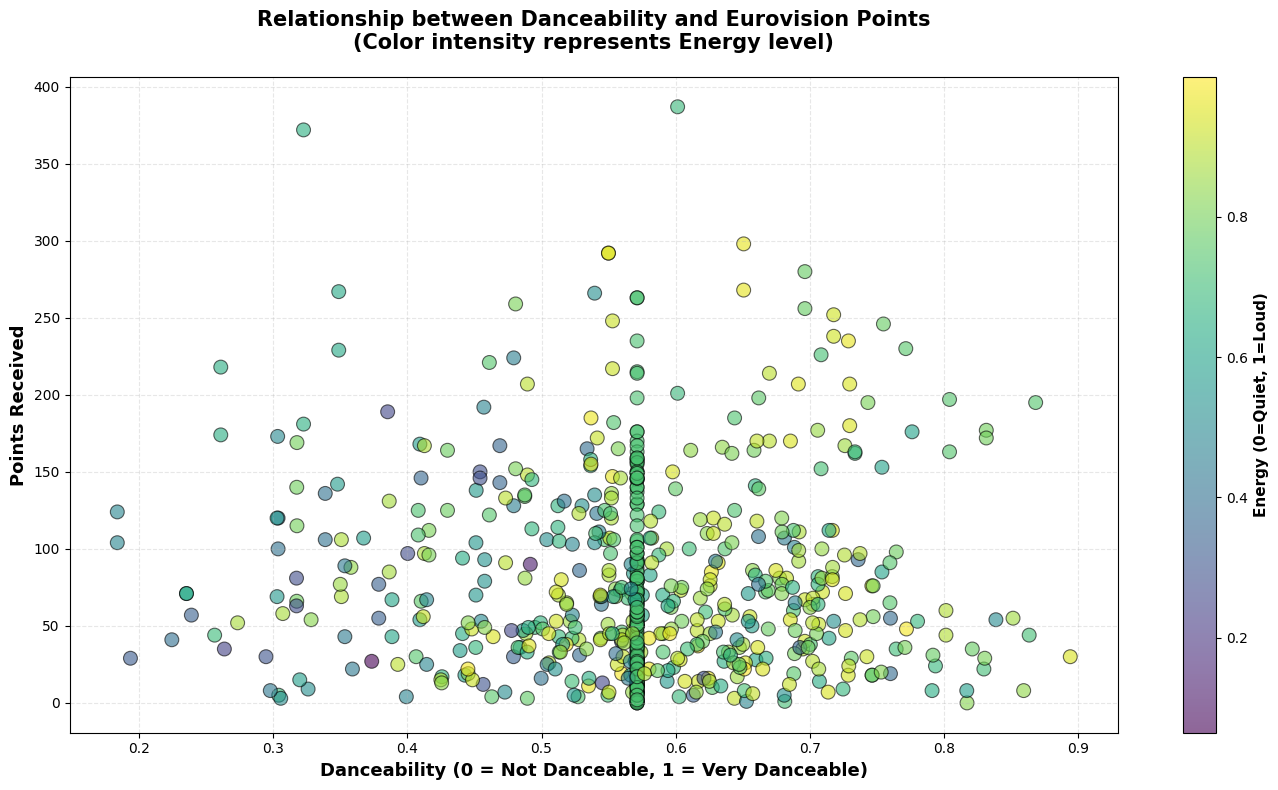


Plot created successfully!


In [44]:
#  Prepare Data for Analysis

print("\n" + "=" * 80)
print("DATA PREPARATION FOR SCATTER PLOT")
print("=" * 80)

# Define our selected features
selected_features = ["energy", "danceability", "speechiness", "acousticness", "liveness"]

# Check if 'Points' column exists
if 'Points' not in eurovision_meta.columns:
    print("\n⚠️  'Points' column not found!")
    print("\nAvailable numeric columns:")
    numeric_cols = eurovision_meta.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        print(f"  • {col}")

    # You might need to use a different column
    # Common alternatives: 'Score', 'Total_Points', 'Final_Points', 'Jury_Points', etc.
    points_col = 'Points'  # Change this if needed
else:
    points_col = 'Points'

# Create a clean dataset with selected features + Points
analysis_data = eurovision_meta[selected_features + [points_col]].copy()

print(f"\nDataset for analysis:")
print(f"  • Selected features: {selected_features}")
print(f"  • Points column: {points_col}")
print(f"  • Original rows: {len(analysis_data)}")

# Remove rows with missing values
analysis_data_clean = analysis_data.dropna()

print(f"  • Rows after removing NaN: {len(analysis_data_clean)}")
print(f"  • Rows removed: {len(analysis_data) - len(analysis_data_clean)}")

print(f"\n\nDescriptive Statistics:")
print(analysis_data_clean[['danceability', points_col]].describe())

# Check for any outliers or unusual values
print(f"\n\nData Quality Check:")
print(f"  Danceability range: {analysis_data_clean['danceability'].min():.2f} to {analysis_data_clean['danceability'].max():.2f}")
print(f"  Points range: {analysis_data_clean[points_col].min():.0f} to {analysis_data_clean[points_col].max():.0f}")

# Cell 3: Create Scatter Plot - Danceability vs Points

print("\n" + "=" * 80)
print("CREATING SCATTER PLOT: DANCEABILITY vs POINTS")
print("=" * 80)

# Create figure with high quality
plt.figure(figsize=(14, 8))

# Create scatter plot
plt.scatter(
    analysis_data_clean['danceability'],
    analysis_data_clean[points_col],
    alpha=0.6,                    # Transparency (0-1)
    s=100,                        # Size of points
    c=analysis_data_clean['energy'],  # Color by energy
    cmap='viridis',               # Color map
    edgecolors='black',           # Border color
    linewidth=0.8                 # Border width
)

# Add labels and title
plt.xlabel('Danceability (0 = Not Danceable, 1 = Very Danceable)',
           fontsize=13, fontweight='bold')
plt.ylabel('Points Received', fontsize=13, fontweight='bold')
plt.title('Relationship between Danceability and Eurovision Points\n(Color intensity represents Energy level)',
          fontsize=15, fontweight='bold', pad=20)

# Add grid for easier reading
plt.grid(True, alpha=0.3, linestyle='--')

# Add colorbar to show energy levels
cbar = plt.colorbar(label='Energy Level')
cbar.set_label('Energy (0=Quiet, 1=Loud)', fontsize=11, fontweight='bold')

# Add some styling
plt.tight_layout()

# Save the figure
plt.savefig('scatter_danceability_vs_points_basic.png', dpi=300, bbox_inches='tight')
print("\n✓ Basic scatter plot saved as 'scatter_danceability_vs_points_basic.png'")
plt.show()

print("\nPlot created successfully!")


CREATING ENHANCED SCATTER PLOT WITH TREND LINE

✓ Enhanced scatter plot saved as 'scatter_danceability_vs_points_enhanced.png'


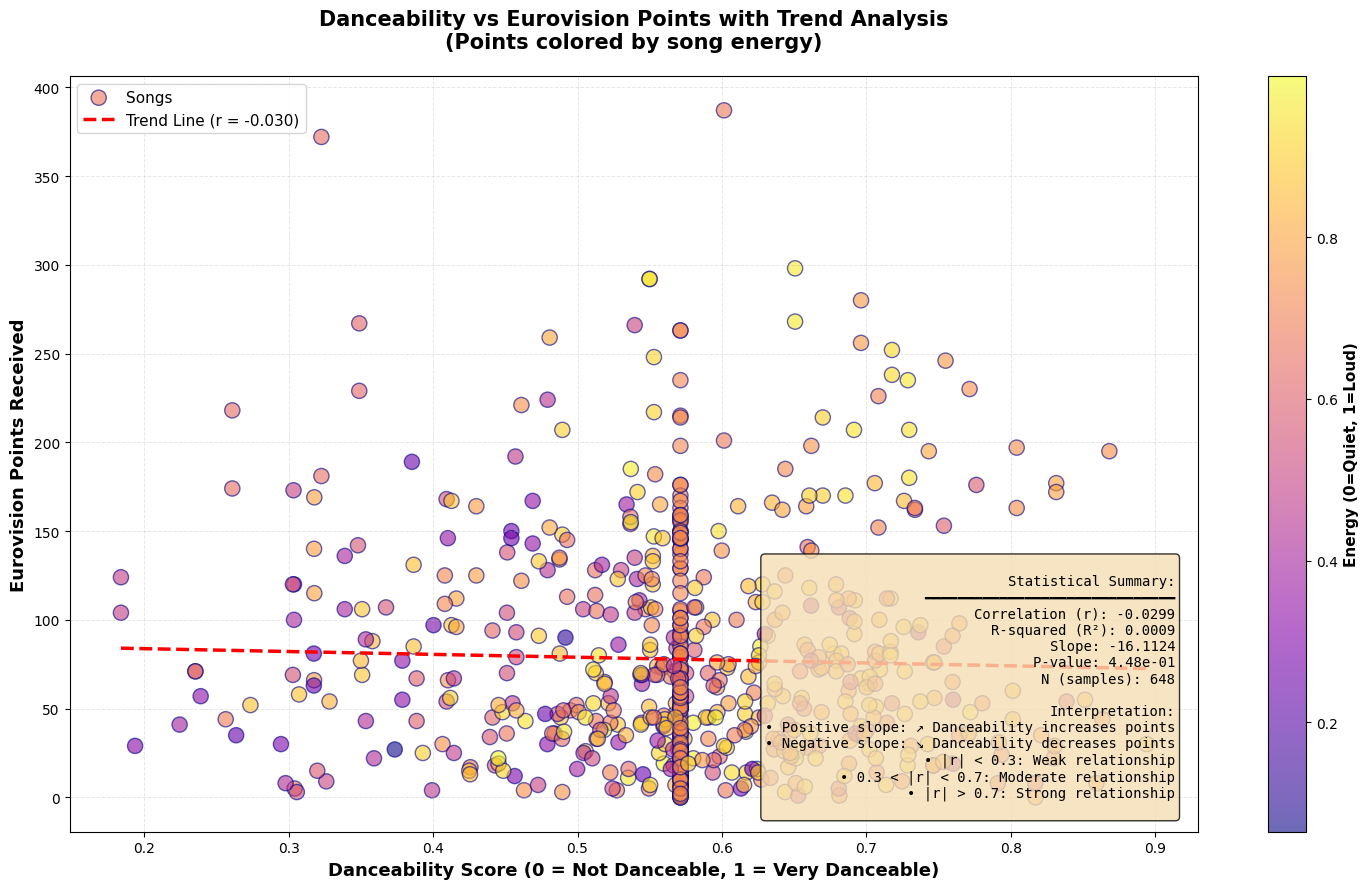


✓ Trend line added
✓ Statistical information displayed

STATISTICAL ANALYSIS: DANCEABILITY vs POINTS

1. CORRELATION ANALYSIS
--------------------------------------------------------------------------------
Pearson Correlation: -0.0299
Spearman Correlation: -0.0426

Interpretation: WEAK NEGATIVE relationship


2. LINEAR REGRESSION ANALYSIS
--------------------------------------------------------------------------------
Equation: Points = -16.1124 × Danceability + 86.9881
R-squared (R²): 0.0009
Slope: -16.1124
Intercept: 86.9881
Standard Error: 21.2092
P-value: 4.48e-01
✗ NOT SIGNIFICANT (p > 0.05) - Relationship may be due to chance


3. SLOPE INTERPRETATION
--------------------------------------------------------------------------------
For every 0.1 increase in danceability:
  → Points change by: -1.61 points

For every 0.5 increase in danceability:
  → Points change by: -8.06 points

For every 1.0 increase in danceability (max increase):
  → Points change by: -16.11 points


4. VAR

In [42]:
#  Enhanced Scatter Plot with Trend Line and Statistics

print("\n" + "=" * 80)
print("CREATING ENHANCED SCATTER PLOT WITH TREND LINE")
print("=" * 80)

# Create figure
fig, ax = plt.subplots(figsize=(15, 9))

# Scatter plot
scatter = ax.scatter(
    analysis_data_clean['danceability'],
    analysis_data_clean[points_col],
    alpha=0.6,
    s=120,
    c=analysis_data_clean['energy'],
    cmap='plasma',
    edgecolors='darkblue',
    linewidth=1,
    label='Songs'
)

# Calculate correlation
correlation = analysis_data_clean['danceability'].corr(analysis_data_clean[points_col])

# Add trend line (linear regression)
z = np.polyfit(analysis_data_clean['danceability'], analysis_data_clean[points_col], 1)
p = np.poly1d(z)
x_line = np.linspace(analysis_data_clean['danceability'].min(),
                     analysis_data_clean['danceability'].max(), 100)
y_line = p(x_line)

ax.plot(x_line, y_line, "r--", linewidth=2.5, label=f'Trend Line (r = {correlation:.3f})')

# Calculate R-squared
slope, intercept, r_value, p_value, std_err = stats.linregress(
    analysis_data_clean['danceability'],
    analysis_data_clean[points_col]
)

# Add labels and formatting
ax.set_xlabel('Danceability Score (0 = Not Danceable, 1 = Very Danceable)',
              fontsize=13, fontweight='bold')
ax.set_ylabel('Eurovision Points Received', fontsize=13, fontweight='bold')
ax.set_title('Danceability vs Eurovision Points with Trend Analysis\n(Points colored by song energy)',
             fontsize=15, fontweight='bold', pad=20)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Energy Level')
cbar.set_label('Energy (0=Quiet, 1=Loud)', fontsize=11, fontweight='bold')

# Add legend
ax.legend(fontsize=11, loc='upper left')

# Add statistics box
stats_text = f"""
Statistical Summary:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Correlation (r): {correlation:.4f}
R-squared (R²): {r_value**2:.4f}
Slope: {slope:.4f}
P-value: {p_value:.2e}
N (samples): {len(analysis_data_clean)}

Interpretation:
• Positive slope: ↗ Danceability increases points
• Negative slope: ↘ Danceability decreases points
• |r| < 0.3: Weak relationship
• 0.3 < |r| < 0.7: Moderate relationship
• |r| > 0.7: Strong relationship
"""

ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontfamily='monospace')

plt.tight_layout()

# Save the figure
plt.savefig('scatter_danceability_vs_points_enhanced.png', dpi=300, bbox_inches='tight')
print("\n✓ Enhanced scatter plot saved as 'scatter_danceability_vs_points_enhanced.png'")
plt.show()

print(f"\n✓ Trend line added")
print(f"✓ Statistical information displayed")
# Cell 5: Detailed Statistical Analysis

print("\n" + "=" * 80)
print("STATISTICAL ANALYSIS: DANCEABILITY vs POINTS")
print("=" * 80)

# Get the two variables
danceability = analysis_data_clean['danceability']
points = analysis_data_clean[points_col]

# 1. Correlation Analysis
print("\n1. CORRELATION ANALYSIS")
print("-" * 80)

pearson_corr = danceability.corr(points)
spearman_corr = danceability.corr(points, method='spearman')

print(f"Pearson Correlation: {pearson_corr:.4f}")
print(f"Spearman Correlation: {spearman_corr:.4f}")

if abs(pearson_corr) < 0.3:
    strength = "WEAK"
elif abs(pearson_corr) < 0.7:
    strength = "MODERATE"
else:
    strength = "STRONG"

direction = "POSITIVE" if pearson_corr > 0 else "NEGATIVE"

print(f"\nInterpretation: {strength} {direction} relationship")

# 2. Linear Regression Analysis
print("\n\n2. LINEAR REGRESSION ANALYSIS")
print("-" * 80)

slope, intercept, r_value, p_value, std_err = stats.linregress(danceability, points)

print(f"Equation: Points = {slope:.4f} × Danceability + {intercept:.4f}")
print(f"R-squared (R²): {r_value**2:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"Standard Error: {std_err:.4f}")
print(f"P-value: {p_value:.2e}")

if p_value < 0.05:
    print(f"✓ SIGNIFICANT (p < 0.05) - Relationship is statistically significant!")
else:
    print(f"✗ NOT SIGNIFICANT (p > 0.05) - Relationship may be due to chance")

# 3. Interpretation of Slope
print("\n\n3. SLOPE INTERPRETATION")
print("-" * 80)

print(f"For every 0.1 increase in danceability:")
print(f"  → Points change by: {slope * 0.1:.2f} points")

print(f"\nFor every 0.5 increase in danceability:")
print(f"  → Points change by: {slope * 0.5:.2f} points")

print(f"\nFor every 1.0 increase in danceability (max increase):")
print(f"  → Points change by: {slope * 1.0:.2f} points")

# 4. Variance Explained
print("\n\n4. VARIANCE EXPLAINED")
print("-" * 80)

variance_explained = r_value**2 * 100

print(f"R-squared: {r_value**2:.4f}")
print(f"Percentage of variance explained: {variance_explained:.2f}%")
print(f"\nInterpretation:")
print(f"  → Danceability explains {variance_explained:.1f}% of the variation in points")
print(f"  → Other factors explain {100 - variance_explained:.1f}% of the variation")

# 5. Distribution Analysis
print("\n\n5. DISTRIBUTION ANALYSIS")
print("-" * 80)

print(f"\nDanceability Distribution:")
print(f"  • Mean: {danceability.mean():.3f}")
print(f"  • Median: {danceability.median():.3f}")
print(f"  • Std Dev: {danceability.std():.3f}")
print(f"  • Range: {danceability.min():.3f} to {danceability.max():.3f}")

print(f"\nPoints Distribution:")
print(f"  • Mean: {points.mean():.1f}")
print(f"  • Median: {points.median():.1f}")
print(f"  • Std Dev: {points.std():.1f}")
print(f"  • Range: {points.min():.0f} to {points.max():.0f}")

# 6. Identify outliers
print("\n\n6. OUTLIER DETECTION")
print("-" * 80)

# Using IQR method for points
Q1_points = points.quantile(0.25)
Q3_points = points.quantile(0.75)
IQR_points = Q3_points - Q1_points

outliers_low = points < (Q1_points - 1.5 * IQR_points)
outliers_high = points > (Q3_points + 1.5 * IQR_points)
outliers = outliers_low | outliers_high

print(f"Outlier songs (unusual points):")
print(f"  • Count: {outliers.sum()}")
print(f"  • Percentage: {(outliers.sum() / len(points) * 100):.1f}%")

if outliers.sum() > 0:
    print(f"\nTop 5 outlier songs:")
    outlier_data = analysis_data_clean[outliers][['danceability', points_col]].sort_values(points_col, ascending=False).head()
    print(outlier_data)

In [43]:
#  Hypothesis Formulation and Validation
# ✅ FIXED - Function defined FIRST, then called

print("\n" + "=" * 80)
print("HYPOTHESIS FORMULATION & VALIDATION")
print("=" * 80)

# ============================================================================
# STEP 1: DEFINE THE FUNCTION FIRST (before using it!)
# ============================================================================

def formulate_hypothesis(corr, r_squared, p_val):
    """
    Generate a hypothesis statement based on statistical analysis.

    Parameters:
    -----------
    corr : float (correlation coefficient, -1 to 1)
    r_squared : float (R-squared value, 0 to 1)
    p_val : float (p-value from test)

    Returns:
    --------
    str : Hypothesis statement
    """

    # NOT SIGNIFICANT
    if p_val > 0.05:
        return "Danceability has a negligible or non-significant effect on Eurovision points. Other factors play a more important role."

    # STRONG POSITIVE
    if abs(corr) > 0.7:
        if corr > 0:
            return f"Highly danceable songs tend to receive significantly more Eurovision points. The relationship is strong and positive (r={corr:.3f})."
        else:
            return f"Highly danceable songs tend to receive significantly fewer Eurovision points. The relationship is strong and negative (r={corr:.3f})."

    # MODERATE POSITIVE/NEGATIVE
    elif abs(corr) > 0.4:
        if corr > 0:
            return f"Danceable songs tend to receive more points, but danceability alone is not a strong predictor. Many other factors influence Eurovision success (r={corr:.3f})."
        else:
            return f"Danceable songs tend to receive fewer points, but the effect is moderate and other factors are important (r={corr:.3f})."

    # WEAK
    else:
        return f"Danceability has weak influence on Eurovision points. The relationship is minimal and other musical/performance factors are likely more important (r={corr:.3f})."


# ============================================================================
# STEP 2: CALCULATE KEY STATISTICS
# ============================================================================

print("\nCalculating statistics...")

correlation = analysis_data_clean['danceability'].corr(analysis_data_clean[points_col])
slope, intercept, r_value, p_value, std_err = stats.linregress(
    analysis_data_clean['danceability'],
    analysis_data_clean[points_col]
)

print("✓ Statistics calculated successfully!\n")


# ============================================================================
# STEP 3: DISPLAY OBSERVED PATTERN
# ============================================================================

print("📊 OBSERVED PATTERN FROM SCATTER PLOT:")
print("-" * 80)

if correlation > 0.3:
    print(f"\n✓ POSITIVE RELATIONSHIP OBSERVED")
    print(f"  • Correlation coefficient: {correlation:.4f}")
    print(f"  • Direction: As danceability INCREASES → Points tend to INCREASE")
    print(f"  • Trend line: UPWARD SLOPING")
elif correlation < -0.3:
    print(f"\n✓ NEGATIVE RELATIONSHIP OBSERVED")
    print(f"  • Correlation coefficient: {correlation:.4f}")
    print(f"  • Direction: As danceability INCREASES → Points tend to DECREASE")
    print(f"  • Trend line: DOWNWARD SLOPING")
else:
    print(f"\n✓ WEAK/NO RELATIONSHIP OBSERVED")
    print(f"  • Correlation coefficient: {correlation:.4f}")
    print(f"  • Direction: Danceability and points are largely INDEPENDENT")
    print(f"  • Trend line: Nearly HORIZONTAL")


# ============================================================================
# STEP 4: ASSESS RELATIONSHIP STRENGTH
# ============================================================================

print(f"\n\n📈 STRENGTH OF RELATIONSHIP:")
print("-" * 80)

strength_score = abs(correlation)
if strength_score < 0.1:
    strength = "NEGLIGIBLE"
elif strength_score < 0.3:
    strength = "WEAK"
elif strength_score < 0.5:
    strength = "MODERATE"
elif strength_score < 0.7:
    strength = "STRONG"
else:
    strength = "VERY STRONG"

print(f"Relationship strength: {strength}")
print(f"R-squared: {r_value**2:.4f} ({r_value**2 * 100:.2f}% variance explained)")


# ============================================================================
# STEP 5: CHECK STATISTICAL SIGNIFICANCE
# ============================================================================

print(f"\n\n🔬 STATISTICAL SIGNIFICANCE:")
print("-" * 80)

if p_value < 0.001:
    print(f"P-value: {p_value:.2e} - HIGHLY SIGNIFICANT (p < 0.001)")
    sig_level = "HIGHLY SIGNIFICANT"
elif p_value < 0.01:
    print(f"P-value: {p_value:.2e} - VERY SIGNIFICANT (p < 0.01)")
    sig_level = "VERY SIGNIFICANT"
elif p_value < 0.05:
    print(f"P-value: {p_value:.4f} - SIGNIFICANT (p < 0.05)")
    sig_level = "SIGNIFICANT"
else:
    print(f"P-value: {p_value:.4f} - NOT SIGNIFICANT (p > 0.05)")
    sig_level = "NOT SIGNIFICANT"

print(f"\n⚠️  Interpretation: The relationship is {sig_level}")
print(f"  → If significant: The pattern is unlikely due to random chance")
print(f"  → If not significant: The pattern could be due to random variation")


# ============================================================================
# STEP 6: FORMULATE HYPOTHESIS (NOW THE FUNCTION IS DEFINED!)
# ============================================================================

print(f"\n\n💡 HYPOTHESIS FORMULATION:")
print("-" * 80)

# Call the function (NOW it's defined, so this works!)
hypothesis_text = formulate_hypothesis(correlation, r_value**2, p_value)

print(f"""
Based on the scatter plot analysis:

NULL HYPOTHESIS (H₀):
  "There is NO relationship between danceability and Eurovision points."

ALTERNATIVE HYPOTHESIS (H₁):
  "There IS a relationship between danceability and Eurovision points."

OBSERVED EVIDENCE:
  • Correlation coefficient: {correlation:.4f}
  • Relationship type: {"POSITIVE" if correlation > 0 else "NEGATIVE" if correlation < 0 else "NONE"}
  • Strength: {strength}
  • R-squared: {r_value**2:.4f}
  • Statistical significance: {sig_level}

DATA INTERPRETATION:
  • {slope:.4f} points change per 0.1 increase in danceability
  • {r_value**2 * 100:.1f}% of point variation is explained by danceability
  • {100 - r_value**2 * 100:.1f}% is explained by other factors

✅ FINAL HYPOTHESIS:
  "{hypothesis_text}"
""")

print("\n" + "=" * 80)
print("✅ HYPOTHESIS FORMULATION COMPLETE!")
print("=" * 80)


HYPOTHESIS FORMULATION & VALIDATION

Calculating statistics...
✓ Statistics calculated successfully!

📊 OBSERVED PATTERN FROM SCATTER PLOT:
--------------------------------------------------------------------------------

✓ WEAK/NO RELATIONSHIP OBSERVED
  • Correlation coefficient: -0.0299
  • Direction: Danceability and points are largely INDEPENDENT
  • Trend line: Nearly HORIZONTAL


📈 STRENGTH OF RELATIONSHIP:
--------------------------------------------------------------------------------
Relationship strength: NEGLIGIBLE
R-squared: 0.0009 (0.09% variance explained)


🔬 STATISTICAL SIGNIFICANCE:
--------------------------------------------------------------------------------
P-value: 0.4477 - NOT SIGNIFICANT (p > 0.05)

⚠️  Interpretation: The relationship is NOT SIGNIFICANT
  → If significant: The pattern is unlikely due to random chance
  → If not significant: The pattern could be due to random variation


💡 HYPOTHESIS FORMULATION:
----------------------------------------------

#Model Training and Evaluation


In [47]:
eurovision_meta.duplicated().sum()

np.int64(0)

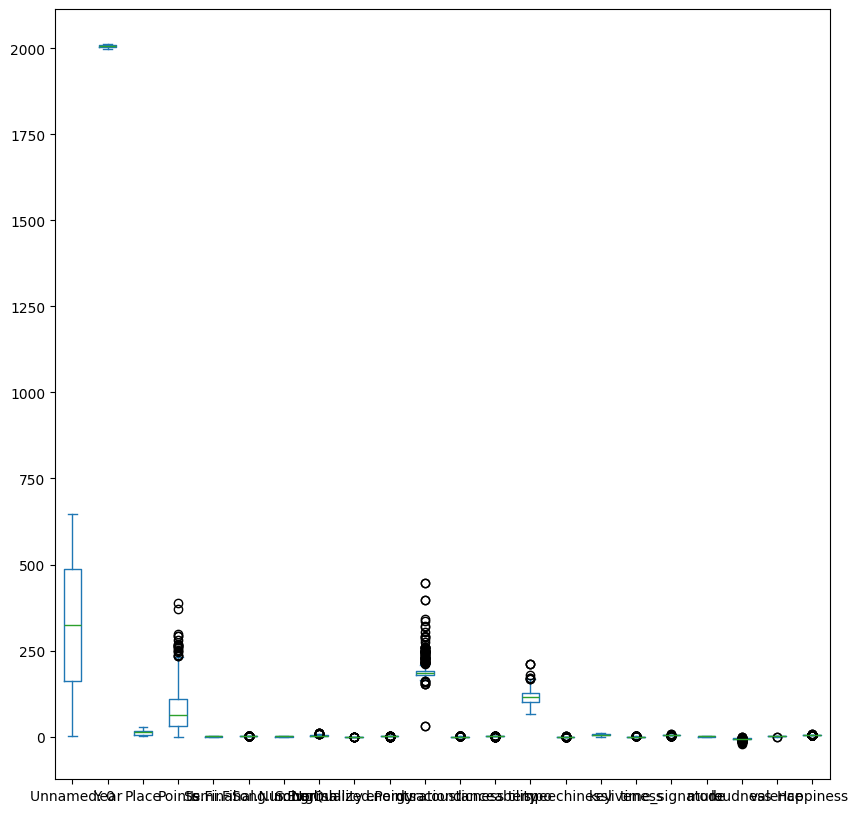

In [48]:
#outlier
data=eurovision_meta.plot(kind='box',figsize=(10,10))

In [51]:

# Select numeric columns
numeric_cols = eurovision_meta.select_dtypes(include=np.number).columns

# IQR method
Q1 = eurovision_meta[numeric_cols].quantile(0.25)
Q3 = eurovision_meta[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Remove outliers
eurovision_clean = eurovision_meta[
    ~((eurovision_meta[numeric_cols] < (Q1 - 1.5 * IQR)) |
      (eurovision_meta[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

In [53]:
eurovision_encoded = pd.get_dummies(
    eurovision_clean,
    columns=['Country','Region','Artist.gender','Group.Solo'],
    drop_first=True
)

In [54]:
# Drop non-useful text columns
X = eurovision_encoded.drop(columns=['Artist','Song','Points'])

# Target variable
y = eurovision_encoded['Points']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# Select numeric features
features = ['danceability','tempo','speechiness','loudness','valence']
X = eurovision_meta[features]

# Target variable
y = eurovision_meta['Points']

# Remove rows with missing values
X = X.dropna()
y = y.loc[X.index]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gradient Boosting Regressor
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 46.584569746612736
